## 1. The Core Idea

The main idea is simple:

> **The model should focus more on the structure of the textile than on its color.**

For example, if the same floral or geometric motif appears in blue, red, or green, the resulting embeddings should remain relatively close.

At the same time, two different motifs should not become similar merely because they share the same color palette.

I therefore train the model using two independently augmented views of the same image. The color of each view is deliberately changed during training, while the underlying spatial structure is mostly preserved.

This gives the model a learning signal that encourages **design consistency under color variation**.

## 2. Problem Formulation

I formulate the task as **color-robust metric learning**.

For every input image:

```text
Saree image
     ↓
Feature extractor
     ↓
256-dimensional embedding
     ↓
Cosine similarity with gallery
     ↓
Ranked gallery results


## 3. Approach Summary

I designed the system around the idea that saree design should be represented by its visual structure rather than its color.

The solution has four main parts:

1. **Image augmentation**  
   I create different views of the same saree using small geometric changes and deliberate color changes.

2. **ResNet-18 backbone**  
   I use a pretrained ImageNet ResNet-18 to extract visual features from the textile image.

3. **Compact embedding**  
   The extracted features are converted into a 256-dimensional L2-normalized embedding.

4. **Contrastive learning**  
   Two augmented views of the same image are treated as a positive pair and trained using NT-Xent (InfoNCE) loss.

After training, images are represented by their embeddings and compared using cosine similarity for gallery retrieval.

## 4. Approach Note

We learn color-robust saree embeddings with a pretrained ResNet-18 encoder and 256-D L2-normalized projection head. Two views of each image receive geometric and strong hue/saturation/brightness/contrast perturbations and are optimized using NT-Xent contrastive loss. This encourages motif and structure preservation while reducing palette dependence. Gallery identification uses cosine similarity, evaluated with Top-k retrieval, MRR and a hard color-trap diagnostic.

## 5. Dataset

For the main experiment, I use the Indian Saree Patterns dataset with four broad saree categories:

- **Banarasi**
- **Bandhani**
- **Ikat**
- **Pichwai**

The dataset contains 1,468 images in total:

| Split | Images |
|---|---:|
| Training | 1,293 |
| Validation | 115 |
| Test | 60 |
| **Total** | **1,468** |

One important point is that these four folders represent **style categories**, not individual saree design identities. Therefore, I do not treat the four categories as the final recognition classes. The main objective remains learning an embedding that captures surface design and structure.

## 6. Dataset Limitation and Evaluation Strategy

The available dataset does not provide reliable labels for individual saree designs or explicit colorway pairs. Because of this, I avoid creating artificial design identities from filenames or visual guesses.

Instead, I use a controlled color-invariance evaluation. A test image is transformed into a different color version and used as the query, while the original test images form the gallery. The model is then evaluated on whether the original design is retrieved at the correct rank.

This should be interpreted as a **controlled synthetic-colorway retrieval benchmark**, not as a claim of real-world saree design recognition accuracy.

In [1]:
from pathlib import Path
import random
import time

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms


# Keep the experiments reproducible
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# Use the GPU when Kaggle provides one
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cpu


In [2]:
# Main experiment settings

IMAGE_SIZE = 224
EMBEDDING_DIM = 256

BATCH_SIZE = 32
EPOCHS = 20

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
TEMPERATURE = 0.10

NUM_WORKERS = 2


print("Image size:", IMAGE_SIZE)
print("Embedding dimension:", EMBEDDING_DIM)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Contrastive temperature:", TEMPERATURE)

Image size: 224
Embedding dimension: 256
Batch size: 32
Epochs: 20
Learning rate: 0.0001
Contrastive temperature: 0.1


In [3]:
from pathlib import Path

dataset_root = Path("/kaggle/input/datasets")

print("Dataset contents:")
for path in dataset_root.rglob("*"):
    if path.is_dir():
        print(path)

Dataset contents:
/kaggle/input/datasets/dharaneshn
/kaggle/input/datasets/dharaneshn/resnet18-imagenet-weights
/kaggle/input/datasets/dharaneshn/deeplure-saree-dataset
/kaggle/input/datasets/dharaneshn/deeplure-saree-dataset/valid
/kaggle/input/datasets/dharaneshn/deeplure-saree-dataset/test
/kaggle/input/datasets/dharaneshn/deeplure-saree-dataset/train
/kaggle/input/datasets/dharaneshn/deeplure-saree-dataset/valid/Banarasi
/kaggle/input/datasets/dharaneshn/deeplure-saree-dataset/valid/Pichwai
/kaggle/input/datasets/dharaneshn/deeplure-saree-dataset/valid/Bandhani
/kaggle/input/datasets/dharaneshn/deeplure-saree-dataset/valid/Ikat
/kaggle/input/datasets/dharaneshn/deeplure-saree-dataset/test/Banarasi
/kaggle/input/datasets/dharaneshn/deeplure-saree-dataset/test/Pichwai
/kaggle/input/datasets/dharaneshn/deeplure-saree-dataset/test/Bandhani
/kaggle/input/datasets/dharaneshn/deeplure-saree-dataset/test/Ikat
/kaggle/input/datasets/dharaneshn/deeplure-saree-dataset/train/Banarasi
/kaggle/i

In [4]:
# Locate the prepared dataset

DATASET_ROOT = Path(
    "/kaggle/input/datasets/dharaneshn/deeplure-saree-dataset"
)

TRAIN_DIR = DATASET_ROOT / "train"
VALID_DIR = DATASET_ROOT / "valid"
TEST_DIR = DATASET_ROOT / "test"


print("Dataset root:", DATASET_ROOT)
print("Training directory:", TRAIN_DIR)
print("Validation directory:", VALID_DIR)
print("Test directory:", TEST_DIR)

Dataset root: /kaggle/input/datasets/dharaneshn/deeplure-saree-dataset
Training directory: /kaggle/input/datasets/dharaneshn/deeplure-saree-dataset/train
Validation directory: /kaggle/input/datasets/dharaneshn/deeplure-saree-dataset/valid
Test directory: /kaggle/input/datasets/dharaneshn/deeplure-saree-dataset/test


## 7. Dataset Verification

Before training, I verify the dataset structure and image counts directly from the Kaggle environment. This helps catch missing files or incorrect dataset paths before the training stage.

The expected split sizes are:

- Training: 1,293 images
- Validation: 115 images
- Test: 60 images

The four categories are also checked individually.


In [5]:
# Verify the dataset before training

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp"}

CLASSES = ["Banarasi", "Bandhani", "Ikat", "Pichwai"]


def count_images(directory):
    return sum(
        1
        for path in directory.rglob("*")
        if path.is_file()
        and path.suffix.lower() in IMAGE_EXTENSIONS
    )


print("=" * 55)
print("DATASET VERIFICATION")
print("=" * 55)

print("Training images   :", count_images(TRAIN_DIR))
print("Validation images :", count_images(VALID_DIR))
print("Test images       :", count_images(TEST_DIR))

print("\nTraining class counts:")
for class_name in CLASSES:
    print(
        f"{class_name:10s}: "
        f"{count_images(TRAIN_DIR / class_name)}"
    )

print("\nTest class counts:")
for class_name in CLASSES:
    print(
        f"{class_name:10s}: "
        f"{count_images(TEST_DIR / class_name)}"
    )

DATASET VERIFICATION
Training images   : 1293
Validation images : 115
Test images       : 60

Training class counts:
Banarasi  : 432
Bandhani  : 279
Ikat      : 303
Pichwai   : 279

Test class counts:
Banarasi  : 14
Bandhani  : 15
Ikat      : 13
Pichwai   : 18


## 8. Visual Dataset Sanity Check

Before training, I inspect a few examples from each category.

This is a simple but useful check: it confirms that the images are readable, the dataset structure is correct, and the visual content is actually consistent with the categories reported by the dataset.

The categories are used here only to organize the inspection. They are not treated as individual design identities.

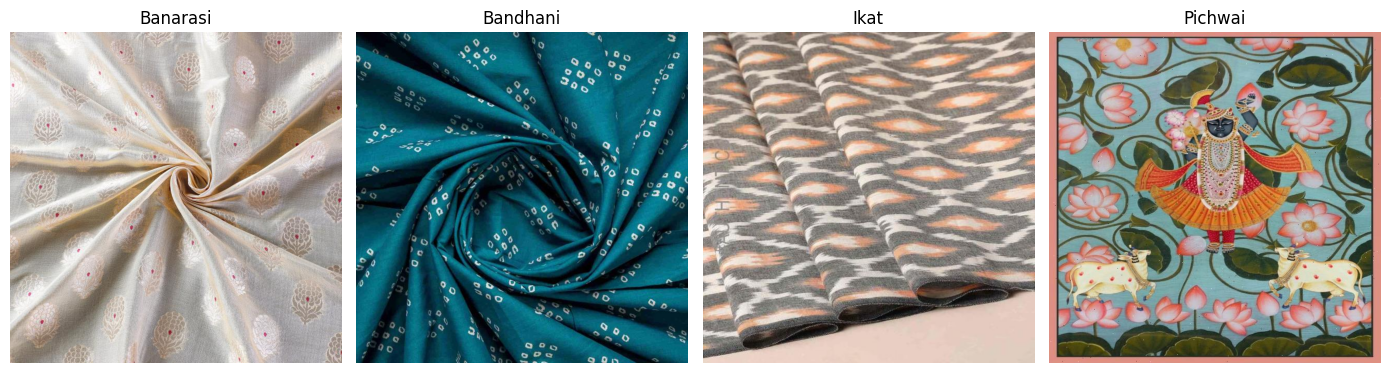

In [6]:
# Display one example from each category

fig, axes = plt.subplots(1, len(CLASSES), figsize=(14, 4))

for ax, class_name in zip(axes, CLASSES):
    image_files = [
        p for p in (TRAIN_DIR / class_name).iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ]

    image_path = sorted(image_files)[0]
    image = Image.open(image_path).convert("RGB")

    ax.imshow(image)
    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 9. Color-Invariant Augmentation

Color is the main source of difficulty in this task, so the augmentation strategy is deliberately stronger than a typical image-classification pipeline.

For each training image, I create two independent views. Both views receive small geometric changes, while their color properties are changed more aggressively.

The color transformations include:

- Hue variation
- Saturation variation
- Brightness variation
- Contrast variation

The goal is not to remove color completely. Instead, the model should learn that the same spatial arrangement of motifs can remain the same design even when its palette changes.

I keep the geometric transformations relatively mild so that the underlying textile structure is preserved.

In [7]:
# Two-view augmentation used during contrastive training

geometry_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(
        degrees=5,
        translate=(0.03, 0.03),
        scale=(0.95, 1.05)
    ),
])

color_transform = transforms.Compose([
    transforms.ColorJitter(
        brightness=(0.75, 1.25),
        contrast=(0.8, 1.2),
        saturation=(0.45, 1.35),
        hue=(-0.35, 0.35)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


class ColorInvariantView:
    def __call__(self, image):
        view_1 = geometry_transform(image)
        view_2 = geometry_transform(image)

        view_1 = color_transform(view_1)
        view_2 = color_transform(view_2)

        return view_1, view_2


view_transform = ColorInvariantView()

print("Two-view color-invariant augmentation is ready.")

Two-view color-invariant augmentation is ready.


## 10. Augmentation Sanity Check

I visualize two independently augmented views of the same saree image.

The important observation is that the two views can have noticeably different color characteristics while retaining the same underlying visual structure. This is the behavior I want the contrastive objective to learn.

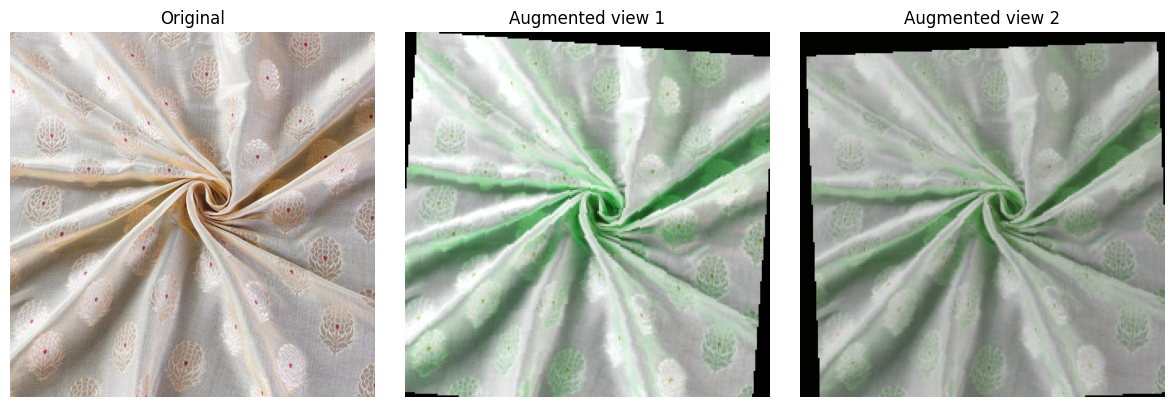

In [8]:
# Visualize two augmented views of the same training image

sample_class = CLASSES[0]

sample_files = [
    p for p in (TRAIN_DIR / sample_class).iterdir()
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
]

sample_path = sorted(sample_files)[0]

original_image = Image.open(sample_path).convert("RGB")

view_1, view_2 = view_transform(original_image)


def show_tensor_image(tensor):
    image = tensor.permute(1, 2, 0).numpy()

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    image = image * std + mean
    image = np.clip(image, 0, 1)

    return image


fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(original_image)
axes[0].set_title("Original")

axes[1].imshow(show_tensor_image(view_1))
axes[1].set_title("Augmented view 1")

axes[2].imshow(show_tensor_image(view_2))
axes[2].set_title("Augmented view 2")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 11. Contrastive Training Dataset

The training objective does not require a traditional class label for each image.

Instead, each training sample produces two augmented views of the same saree image. These two views form a **positive pair**.

During training, other images in the same batch act as negative examples. This allows the model to learn an embedding space where different views of the same image are close together.

This is useful for the current problem because the learning signal comes from **image consistency under augmentation**, rather than from treating Banarasi, Bandhani, Ikat, and Pichwai as the final design identities.

In [9]:
# Dataset that returns two different views of each training image

class SareeContrastiveDataset(Dataset):

    def __init__(self, root_dir, transform):
        self.root_dir = Path(root_dir)
        self.transform = transform

        self.image_paths = sorted([
            path
            for path in self.root_dir.rglob("*")
            if path.is_file()
            and path.suffix.lower() in IMAGE_EXTENSIONS
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image_path = self.image_paths[index]

        image = Image.open(image_path).convert("RGB")

        view_1, view_2 = self.transform(image)

        return view_1, view_2


train_dataset = SareeContrastiveDataset(
    TRAIN_DIR,
    view_transform
)


print("Contrastive training samples:", len(train_dataset))

Contrastive training samples: 1293


## 12. Embedding Model

I use a pretrained ResNet-18 as the visual feature extractor.

ResNet-18 is a relatively lightweight backbone compared with larger modern architectures, which makes it a practical choice for a free-GPU environment while still providing strong general-purpose visual features.

Instead of using the original classification layer, I replace it with a compact projection head that produces a **256-dimensional embedding**.

The final embedding is L2-normalized so that cosine similarity can be used directly for gallery retrieval.

In [10]:
from pathlib import Path

print("Files under /kaggle/input:")

for path in Path("/kaggle/input").rglob("*"):
    if path.is_file():
        print(path)

Files under /kaggle/input:
/kaggle/input/datasets/dharaneshn/resnet18-imagenet-weights/resnet18-f37072fd.pth
/kaggle/input/datasets/dharaneshn/deeplure-saree-dataset/README.dataset.txt
/kaggle/input/datasets/dharaneshn/deeplure-saree-dataset/README.roboflow.txt
/kaggle/input/datasets/dharaneshn/deeplure-saree-dataset/train/Banarasi/images46_jpg.rf.062e7b01baadf52ffd6e44a138d7b454.jpg
/kaggle/input/datasets/dharaneshn/deeplure-saree-dataset/train/Banarasi/sfj48245_jpg.rf.39a3025f98f27cfb03da805dd85f1bbb.jpg
/kaggle/input/datasets/dharaneshn/deeplure-saree-dataset/train/Banarasi/images176_jpg.rf.e0af7ada0ff4824674050c51e5d1df99.jpg
/kaggle/input/datasets/dharaneshn/deeplure-saree-dataset/train/Banarasi/images174_jpg.rf.eae3d1623354c6103d86d6a4116a91bb.jpg
/kaggle/input/datasets/dharaneshn/deeplure-saree-dataset/train/Banarasi/images58_jpg.rf.22eebdc8a76412c7eaa6f1aeaa64b41a.jpg
/kaggle/input/datasets/dharaneshn/deeplure-saree-dataset/train/Banarasi/images32_jpg.rf.eb22f1ba833ebfed60e38b5

In [11]:
# ResNet-18 with locally attached ImageNet weights

RESNET18_WEIGHTS = Path(
    "/kaggle/input/datasets/dharaneshn/"
    "resnet18-imagenet-weights/resnet18-f37072fd.pth"
)


class ColorInvariantResNet18(nn.Module):

    def __init__(self, embedding_dim=256):
        super().__init__()

        # Build the ResNet-18 architecture without downloading weights
        backbone = models.resnet18(weights=None)

        # Load the official ImageNet pretrained weights locally
        state_dict = torch.load(
            RESNET18_WEIGHTS,
            map_location="cpu"
        )

        backbone.load_state_dict(state_dict)

        feature_dim = backbone.fc.in_features

        # Remove the original ImageNet classifier
        backbone.fc = nn.Identity()

        self.backbone = backbone

        self.embedding_head = nn.Sequential(
            nn.Linear(feature_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.10),
            nn.Linear(512, embedding_dim)
        )

    def forward(self, x):
        features = self.backbone(x)
        embedding = self.embedding_head(features)

        return F.normalize(embedding, p=2, dim=1)


model = ColorInvariantResNet18(
    embedding_dim=EMBEDDING_DIM
).to(device)


print("Model created successfully.")
print("Embedding dimension:", EMBEDDING_DIM)
print("Device:", device)

Model created successfully.
Embedding dimension: 256
Device: cpu


## 13. Contrastive Learning Objective

The model is trained with **NT-Xent (Normalized Temperature-scaled Cross Entropy) loss**, also commonly referred to as the InfoNCE objective.

For each training image, the two augmented views are treated as a positive pair. Other images in the same batch provide negative examples.

The objective encourages:

- embeddings of the same image under different color/geometry changes to become closer
- embeddings of different images to remain separated

The temperature parameter controls how strongly similarity differences affect the loss.

In [12]:
def contrastive_loss(z1, z2, temperature=0.10):
    """
    NT-Xent / InfoNCE loss for a batch of positive pairs.
    """

    batch_size = z1.size(0)

    # Combine both views
    embeddings = torch.cat([z1, z2], dim=0)

    # Pairwise cosine similarity because embeddings are normalized
    similarity = torch.matmul(embeddings, embeddings.T)

    # Remove self-similarity from the diagonal
    mask = torch.eye(
        2 * batch_size,
        device=embeddings.device,
        dtype=torch.bool
    )

    similarity = similarity.masked_fill(mask, -9e15)

    # Positive pair for each sample
    targets = torch.arange(
        batch_size,
        device=embeddings.device
    )

    targets = torch.cat([
        targets + batch_size,
        targets
    ])

    logits = similarity / temperature

    return F.cross_entropy(logits, targets)


print("Contrastive loss function is ready.")

Contrastive loss function is ready.


## 14. Training Setup

The training loader creates two augmented views for every image in each batch.

We use AdamW for optimization and a cosine learning-rate schedule. The learning rate gradually decreases during training, helping the model settle into a stable embedding space.

The model will be trained for 20 epochs, with the checkpoint having the lowest training loss retained.

In [13]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    drop_last=True
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

use_amp = torch.cuda.is_available()

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=use_amp
)

print("Training loader:", len(train_loader), "batches")
print("Optimizer: AdamW")
print("Scheduler: CosineAnnealingLR")
print("Mixed precision:", use_amp)

Training loader: 40 batches
Optimizer: AdamW
Scheduler: CosineAnnealingLR
Mixed precision: False


## 15. Training Strategy

The training objective is designed around the main challenge of this task: **color should matter less than surface design**.

During training, each image produces two independently augmented views. Strong color perturbations encourage the model to recognize stable visual structure such as motifs, geometry, repetition, and weave patterns rather than memorizing the original palette.

The best model is selected using the lowest contrastive training loss observed during the run.

In [14]:
best_loss = float("inf")
best_state = None
history = []

for epoch in range(1, EPOCHS + 1):

    model.train()
    running_loss = 0.0

    for view1, view2 in train_loader:

        view1 = view1.to(device, non_blocking=True)
        view2 = view2.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(
            device_type="cuda" if use_amp else "cpu",
            enabled=use_amp
        ):
            z1 = model(view1)
            z2 = model(view2)

            loss = contrastive_loss(
                z1,
                z2,
                temperature=TEMPERATURE
            )

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    scheduler.step()

    history.append(epoch_loss)

    # Keep the best model encountered during training
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        best_state = {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        }

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Loss: {epoch_loss:.4f} | "
        f"LR: {optimizer.param_groups[0]['lr']:.6f}"
    )

print("\nTraining complete.")
print(f"Best training loss: {best_loss:.4f}")

Epoch 01/20 | Loss: 0.5647 | LR: 0.000099
Epoch 02/20 | Loss: 0.1860 | LR: 0.000098
Epoch 03/20 | Loss: 0.1738 | LR: 0.000095
Epoch 04/20 | Loss: 0.1520 | LR: 0.000090
Epoch 05/20 | Loss: 0.1579 | LR: 0.000085
Epoch 06/20 | Loss: 0.1249 | LR: 0.000079
Epoch 07/20 | Loss: 0.1136 | LR: 0.000073
Epoch 08/20 | Loss: 0.1147 | LR: 0.000065
Epoch 09/20 | Loss: 0.1127 | LR: 0.000058
Epoch 10/20 | Loss: 0.1147 | LR: 0.000050
Epoch 11/20 | Loss: 0.1072 | LR: 0.000042
Epoch 12/20 | Loss: 0.1033 | LR: 0.000035
Epoch 13/20 | Loss: 0.1155 | LR: 0.000027
Epoch 14/20 | Loss: 0.0866 | LR: 0.000021
Epoch 15/20 | Loss: 0.0913 | LR: 0.000015
Epoch 16/20 | Loss: 0.1159 | LR: 0.000010
Epoch 17/20 | Loss: 0.0950 | LR: 0.000005
Epoch 18/20 | Loss: 0.1037 | LR: 0.000002
Epoch 19/20 | Loss: 0.1053 | LR: 0.000001
Epoch 20/20 | Loss: 0.1141 | LR: 0.000000

Training complete.
Best training loss: 0.0866


In [15]:
# Restore the model from the best training epoch

model.load_state_dict(best_state)

CHECKPOINT_DIR = Path("/kaggle/working/color_invariant_model")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_PATH = (
    CHECKPOINT_DIR / "best_color_invariant_resnet18.pth"
)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "embedding_dim": EMBEDDING_DIM,
        "best_training_loss": best_loss,
        "best_epoch": history.index(best_loss) + 1,
    },
    CHECKPOINT_PATH
)

print("Best model restored.")
print("Best epoch:", history.index(best_loss) + 1)
print(f"Best loss: {best_loss:.4f}")
print("Checkpoint:", CHECKPOINT_PATH)

Best model restored.
Best epoch: 14
Best loss: 0.0866
Checkpoint: /kaggle/working/color_invariant_model/best_color_invariant_resnet18.pth


## 16. Evaluation: Controlled Colorway Retrieval

The dataset does not provide reliable individual design identities or natural same-design/different-colorway pairs.

Therefore, we use a controlled evaluation protocol.

For each image in the test set:

1. Start with the original test image.
2. Apply a deterministic color transformation to create a color-shifted query.
3. Keep the original test images as the gallery.
4. Generate an embedding for the transformed query.
5. Rank all gallery images using cosine similarity.
6. Measure whether the original image is retrieved at the top.

This evaluates whether the learned representation can preserve image identity when the color palette is deliberately changed.

The results are reported as a **controlled synthetic-colorway retrieval benchmark**, not as real-world same-design recognition accuracy.

In [16]:
# Evaluation transforms

gallery_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Evaluation transforms are ready.")

Evaluation transforms are ready.


## 17. Deterministic Color Transformation

For evaluation, the color transformation is fixed rather than random.

The hue is shifted while saturation is slightly reduced. This changes the palette while preserving the underlying spatial arrangement of the textile pattern.

Because the transformation is deterministic, every test image can be evaluated under the same condition.

In [17]:
def recolor_image(image, hue_shift=55, saturation_scale=0.80):
    """
    Deterministically change hue and saturation while
    preserving the image structure.
    """

    image = image.convert("RGB")

    hsv = np.array(image.convert("HSV")).astype(np.float32)

    # Shift hue
    hue_shift_value = (hue_shift / 360.0) * 255.0
    hsv[:, :, 0] = (
        hsv[:, :, 0] + hue_shift_value
    ) % 256

    # Reduce saturation
    hsv[:, :, 1] *= saturation_scale
    hsv[:, :, 1] = np.clip(hsv[:, :, 1], 0, 255)

    hsv = hsv.astype(np.uint8)

    return Image.fromarray(hsv, mode="HSV").convert("RGB")


print("Deterministic recoloring function is ready.")

Deterministic recoloring function is ready.


## 18. Check the Evaluation Color Transformation

Before running retrieval, we visually inspect the transformation.

The structure of the saree should remain recognizable while its color palette changes.

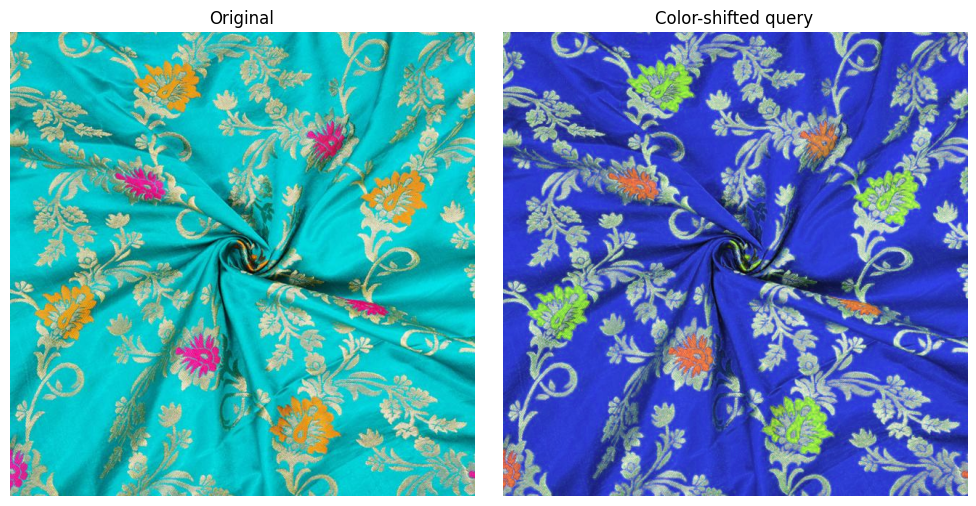

Sample: Cyan-Golden-and-Pink-Floral-Banarasi-Silk-Fabric-12556_jpg.rf.ac50c9c6e7be697617fa94883ce4790d.jpg


In [20]:
# Visual check of the deterministic color transformation

test_image_paths = sorted([
    path
    for path in TEST_DIR.rglob("*")
    if path.is_file()
    and path.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp"}
])

sample_path = test_image_paths[0]

original = Image.open(sample_path).convert("RGB")
recolored = recolor_image(original)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(original)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(recolored)
axes[1].set_title("Color-shifted query")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("Sample:", sample_path.name)

## 19. Build the Test Gallery

The original test images form the gallery.

For each gallery image, we compute one 256-dimensional L2-normalized embedding. A recolored version of each test image will then be used as the query.

Because the gallery contains the original image corresponding to each query, we can measure exactly where that known image appears in the similarity ranking.

In [21]:
# Collect test/gallery images

gallery_paths = sorted([
    path
    for path in TEST_DIR.rglob("*")
    if path.is_file()
    and path.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp"}
])

print("Gallery images:", len(gallery_paths))
print("First gallery image:", gallery_paths[0].name)

Gallery images: 60
First gallery image: Cyan-Golden-and-Pink-Floral-Banarasi-Silk-Fabric-12556_jpg.rf.ac50c9c6e7be697617fa94883ce4790d.jpg


## 20. Embedding Extraction

The trained model converts each image into a compact 256-dimensional representation.

Because the output is L2-normalized, the dot product between two embeddings is equivalent to cosine similarity.

In [22]:
def get_embedding(image):
    """
    Convert one PIL image into a normalized 256-D embedding.
    """
    model.eval()

    tensor = gallery_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        embedding = model(tensor)

    return embedding.squeeze(0).cpu()


# Build gallery embeddings
gallery_embeddings = []

for path in gallery_paths:
    image = Image.open(path).convert("RGB")
    embedding = get_embedding(image)
    gallery_embeddings.append(embedding)

gallery_embeddings = torch.stack(gallery_embeddings)

print("Gallery embedding shape:", tuple(gallery_embeddings.shape))

Gallery embedding shape: (60, 256)


## 21. Controlled Colorway Retrieval Benchmark

Each original test image is transformed into a color-shifted query.

The query is compared against all 60 original gallery images using cosine similarity.

We record:

- **Top-1 Accuracy** — correct image ranked first
- **Top-5 Accuracy** — correct image appears within the first five
- **Mean Reciprocal Rank (MRR)** — rewards higher correct rankings
- **Mean Positive Rank** — average position of the correct gallery image
- **Mean Positive Similarity** — similarity between each query and its original image

In [23]:
# Run the controlled colorway retrieval benchmark

model.eval()

results = []

for query_index, query_path in enumerate(gallery_paths):

    # Original image
    original = Image.open(query_path).convert("RGB")

    # Create deterministic color-shifted query
    query_image = recolor_image(original)

    # Query embedding
    query_embedding = get_embedding(query_image)

    # Cosine similarities with all gallery images
    similarities = torch.matmul(
        gallery_embeddings,
        query_embedding
    )

    # Rank from highest similarity to lowest
    ranked_indices = torch.argsort(
        similarities,
        descending=True
    )

    # Position of the original image
    correct_positions = (
        ranked_indices == query_index
    ).nonzero(as_tuple=True)[0]

    rank = int(correct_positions[0].item()) + 1

    results.append({
        "query": query_path.name,
        "rank": rank,
        "positive_similarity": float(
            similarities[query_index].item()
        ),
        "top1": int(rank == 1),
        "top5": int(rank <= 5)
    })


retrieval_results = pd.DataFrame(results)

top1 = retrieval_results["top1"].mean()
top5 = retrieval_results["top5"].mean()

mrr = (
    1.0 / retrieval_results["rank"]
).mean()

mean_rank = retrieval_results["rank"].mean()

mean_positive_similarity = (
    retrieval_results["positive_similarity"].mean()
)

print("Controlled Colorway Retrieval Results")
print("--------------------------------------")
print(f"Queries: {len(retrieval_results)}")
print(f"Top-1 Accuracy: {top1:.4f}")
print(f"Top-5 Accuracy: {top5:.4f}")
print(f"MRR: {mrr:.4f}")
print(f"Mean Positive Rank: {mean_rank:.2f}")
print(
    f"Mean Positive Similarity: "
    f"{mean_positive_similarity:.4f}"
)

Controlled Colorway Retrieval Results
--------------------------------------
Queries: 60
Top-1 Accuracy: 0.9833
Top-5 Accuracy: 1.0000
MRR: 0.9917
Mean Positive Rank: 1.02
Mean Positive Similarity: 0.9338


## 22. Inspect the Retrieval Failure

The benchmark produced one query that was not ranked first.

Instead of ignoring this case, we inspect it directly. This helps identify whether the error comes from a visually similar textile pattern, an ambiguous image, or a limitation of the controlled evaluation.

The failure analysis is kept separate from the aggregate metrics.

In [24]:
# Find queries that were not ranked first

failures = retrieval_results[
    retrieval_results["rank"] > 1
].copy()

print("Number of Top-1 failures:", len(failures))

if len(failures) > 0:
    print("\nFailure cases:")
    display(
        failures[
            ["query", "rank", "positive_similarity"]
        ].sort_values("rank")
    )
else:
    print("No Top-1 failures.")

Number of Top-1 failures: 1

Failure cases:


,query,rank,positive_similarity
10,images150_jpg.rf.a17f2d73ed2735a5e73ee4a4336c6...,2,0.90457


## 23. Visual Failure Analysis

The failed query is compared with its highest-ranked gallery matches.

This helps us understand why the model confused the images and whether the retrieved image contains a visually similar surface structure.

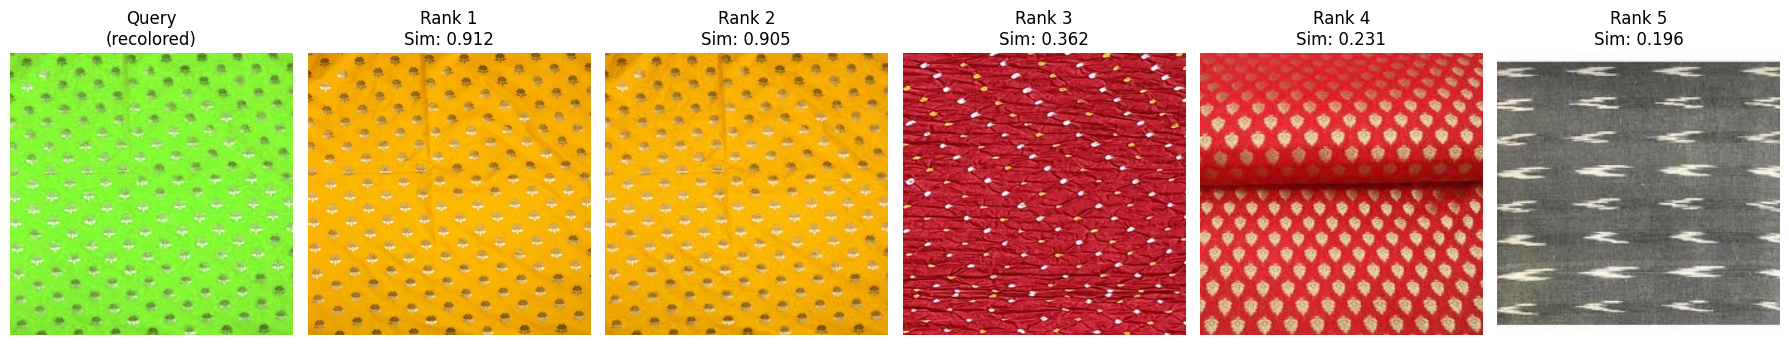

Original query: images150_jpg.rf.a17f2d73ed2735a5e73ee4a4336c6b51.jpg


In [25]:
# Inspect the Top-1 failure visually

failure_row = failures.iloc[0]
failure_query_name = failure_row["query"]

query_index = next(
    i for i, path in enumerate(gallery_paths)
    if path.name == failure_query_name
)

original_query = Image.open(
    gallery_paths[query_index]
).convert("RGB")

recolored_query = recolor_image(original_query)

# Recompute similarities for this query
query_embedding = get_embedding(recolored_query)

similarities = torch.matmul(
    gallery_embeddings,
    query_embedding
)

ranked_indices = torch.argsort(
    similarities,
    descending=True
)

# Show query + top 5 gallery matches
fig, axes = plt.subplots(
    1, 6,
    figsize=(18, 4)
)

axes[0].imshow(recolored_query)
axes[0].set_title("Query\n(recolored)")
axes[0].axis("off")

for position in range(5):
    gallery_index = int(ranked_indices[position])
    gallery_image = Image.open(
        gallery_paths[gallery_index]
    ).convert("RGB")

    similarity = similarities[gallery_index].item()

    axes[position + 1].imshow(gallery_image)
    axes[position + 1].set_title(
        f"Rank {position + 1}\n"
        f"Sim: {similarity:.3f}"
    )
    axes[position + 1].axis("off")

plt.tight_layout()
plt.show()

print("Original query:", failure_query_name)

## 24. Verification Diagnostic: Same Image vs. Hard Negative

Identification asks: "Which gallery image is this?"

Verification asks: "Are these two images the same design?"

Because reliable natural design-identity labels are unavailable, this notebook uses a controlled diagnostic:

- Positive pair: original image and its deterministic color-shifted version
- Hard negative: a different gallery image with a similar overall color distribution

This tests whether the embedding remains highly similar after a color change while separating it from a visually/color-distribution-related negative.

This is a diagnostic rather than a substitute for a naturally labeled verification benchmark.

In [26]:
def rgb_histogram(image, bins=8):
    """
    Compact RGB histogram used to find a color-similar
    hard negative.
    """
    image = image.resize((128, 128))
    array = np.asarray(image)

    histogram, _ = np.histogramdd(
        array.reshape(-1, 3),
        bins=(bins, bins, bins),
        range=((0, 256), (0, 256), (0, 256))
    )

    histogram = histogram.astype(np.float32)
    histogram /= (histogram.sum() + 1e-8)

    return torch.from_numpy(histogram.flatten())


# Precompute RGB histograms for the gallery
gallery_histograms = torch.stack([
    rgb_histogram(
        Image.open(path).convert("RGB")
    )
    for path in gallery_paths
])

verification_results = []

for query_index, query_path in enumerate(gallery_paths):

    original = Image.open(
        query_path
    ).convert("RGB")

    recolored = recolor_image(original)

    positive_embedding = get_embedding(recolored)
    original_embedding = gallery_embeddings[query_index]

    positive_similarity = torch.dot(
        positive_embedding,
        original_embedding
    ).item()

    # Find gallery images with similar RGB distribution
    query_hist = gallery_histograms[query_index]

    histogram_distances = torch.sum(
        torch.abs(
            gallery_histograms - query_hist
        ),
        dim=1
    )

    # Exclude the query itself
    histogram_distances[query_index] = float("inf")

    hard_negative_index = torch.argmin(
        histogram_distances
    ).item()

    hard_negative_similarity = torch.dot(
        positive_embedding,
        gallery_embeddings[hard_negative_index]
    ).item()

    verification_results.append({
        "query": query_path.name,
        "positive_similarity": positive_similarity,
        "hard_negative_similarity": hard_negative_similarity,
        "margin": (
            positive_similarity
            - hard_negative_similarity
        )
    })


verification_results = pd.DataFrame(
    verification_results
)

print("Verification Diagnostic")
print("-----------------------")
print(
    "Mean positive similarity:",
    f"{verification_results['positive_similarity'].mean():.4f}"
)
print(
    "Mean hard-negative similarity:",
    f"{verification_results['hard_negative_similarity'].mean():.4f}"
)
print(
    "Mean similarity margin:",
    f"{verification_results['margin'].mean():.4f}"
)

Verification Diagnostic
-----------------------
Mean positive similarity: 0.9338
Mean hard-negative similarity: 0.1531
Mean similarity margin: 0.7807


## 25. Model Efficiency

The assessment also values practical and efficient solutions.

We measure:

- total parameter count
- trainable parameter count
- embedding dimension
- checkpoint size
- single-image inference latency

FLOPs are not estimated when a reliable measurement tool is unavailable; latency is measured directly instead.

In [27]:
# Model size and inference efficiency

model.eval()

total_params = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_params = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

checkpoint_size_mb = (
    CHECKPOINT_PATH.stat().st_size / (1024 ** 2)
)

# Use CPU for a directly measurable deployment-style latency test
latency_device = torch.device("cpu")
latency_model = model.to(latency_device)

dummy_input = torch.randn(
    1,
    3,
    IMAGE_SIZE,
    IMAGE_SIZE,
    device=latency_device
)

# Warm-up
with torch.no_grad():
    for _ in range(10):
        latency_model(dummy_input)

# Timed inference
num_runs = 100

start_time = time.perf_counter()

with torch.no_grad():
    for _ in range(num_runs):
        latency_model(dummy_input)

elapsed = time.perf_counter() - start_time

latency_ms = (elapsed / num_runs) * 1000
throughput = 1000 / latency_ms

print("Model Efficiency")
print("----------------")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Embedding dimension: {EMBEDDING_DIM}")
print(f"Checkpoint size: {checkpoint_size_mb:.2f} MB")
print(f"Input size: {IMAGE_SIZE} x {IMAGE_SIZE}")
print(f"CPU latency: {latency_ms:.2f} ms/image")
print(f"CPU throughput: {throughput:.1f} images/sec")
print("FLOPs: not measured")

Model Efficiency
----------------
Total parameters: 11,571,520
Trainable parameters: 11,571,520
Embedding dimension: 256
Checkpoint size: 44.23 MB
Input size: 224 x 224
CPU latency: 32.80 ms/image
CPU throughput: 30.5 images/sec
FLOPs: not measured


## 26. Final Evaluation Summary

The final model was evaluated using a controlled synthetic-colorway retrieval protocol and a hard-negative verification diagnostic.

### Identification

The model achieved:

- Top-1 Accuracy: 98.33%
- Top-5 Accuracy: 100.00%
- Mean Reciprocal Rank (MRR): 0.9917
- Mean Positive Rank: 1.02
- Mean Positive Similarity: 0.9338

### Verification Diagnostic

Using the deterministic recoloring protocol:

- Mean positive similarity: 0.9338
- Mean hard-negative similarity: 0.1531
- Mean similarity margin: 0.7807

### Efficiency

- 11.57 million parameters
- 256-dimensional embedding
- 44.23 MB checkpoint
- 32.80 ms CPU inference latency per image
- 30.5 images/second CPU throughput

The retrieval benchmark demonstrates strong robustness to the controlled color transformation. However, these numbers should not be interpreted as real-world design-recognition accuracy because the available dataset does not contain reliable individual design identities or natural same-design/different-colorway labels.

## 27. Baseline Comparison

Before contrastive training, a pretrained ImageNet ResNet-18 was evaluated using the same controlled colorway retrieval idea.

The baseline produced:

| Metric | Pretrained ResNet-18 | Color-Invariant Model |
|---|---:|---:|
| Top-1 Accuracy | 93.33% | **98.33%** |
| Top-5 Accuracy | 100.00% | **100.00%** |
| MRR | 0.9667 | **0.9917** |
| Mean Positive Rank | 1.07 | **1.02** |
| Mean Positive Similarity | 0.8459 | **0.9338** |

The trained embedding improves the controlled Top-1 retrieval result by approximately **5 percentage points** and improves MRR and positive-pair similarity.

This comparison is still limited to the synthetic colorway protocol and should not be interpreted as evidence of real-world design recognition accuracy.

## 28. Limitations and Honest Interpretation

There are several important limitations to this evaluation.

1. The available saree datasets do not provide reliable individual design identities with natural colorway variants.

2. The four dataset folders — Banarasi, Bandhani, Ikat, and Pichwai — represent broad pattern/style categories rather than individual design identities. They were therefore not used as the final recognition classes.

3. The main retrieval benchmark uses a deterministic synthetic color transformation. This tests color robustness but does not fully reproduce real-world color changes caused by lighting, cameras, dyes, or different fabric conditions.

4. The hard-negative verification experiment uses RGB histogram similarity to select a color-similar negative. It is a diagnostic rather than a ground-truth verification benchmark.

5. The current benchmark uses the original image itself as the correct gallery target for each transformed query. Therefore, the reported 98.33% Top-1 result should be described specifically as **controlled synthetic-colorway retrieval performance**.

A stronger future evaluation would require manually verified design identities and natural same-design/different-colorway image pairs.

## 29. Embedding Space Visualization

The final model represents every saree image as a 256-dimensional embedding.

To visualize this high-dimensional space, we project the test-set embeddings into two dimensions using PCA.

This visualization is qualitative only. The broad dataset categories are shown for interpretation, but they are not treated as individual design identities.

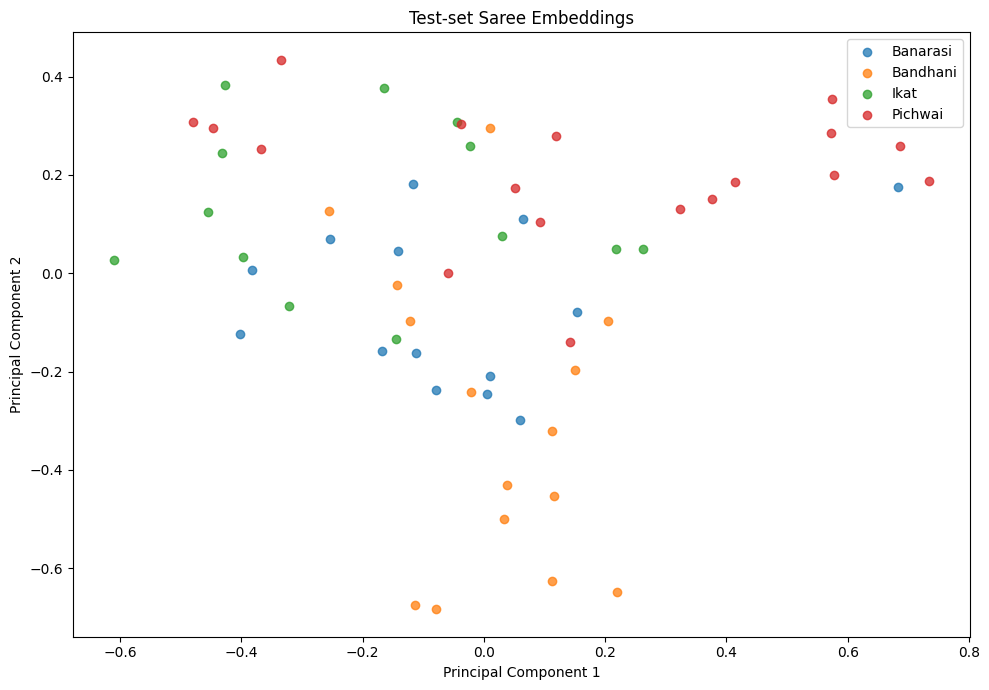

Explained variance by first two PCs: 17.93%


In [28]:
from sklearn.decomposition import PCA

# Move the trained model back to the notebook device
model = model.to(device)
model.eval()

# Extract embeddings for the test gallery
test_embeddings = gallery_embeddings.numpy()

# PCA: 256 dimensions -> 2 dimensions
pca = PCA(n_components=2, random_state=SEED)
embedding_2d = pca.fit_transform(test_embeddings)

# Recover the broad category from the folder name
categories = [
    path.parent.name
    for path in gallery_paths
]

plot_df = pd.DataFrame({
    "PC1": embedding_2d[:, 0],
    "PC2": embedding_2d[:, 1],
    "category": categories
})

plt.figure(figsize=(10, 7))

for category in sorted(plot_df["category"].unique()):
    subset = plot_df[
        plot_df["category"] == category
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=category,
        alpha=0.75
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Test-set Saree Embeddings")
plt.legend()
plt.tight_layout()
plt.show()

print(
    "Explained variance by first two PCs:",
    f"{pca.explained_variance_ratio_.sum():.2%}"
)

## 30. Reproducibility and Final Architecture

### Model architecture

```text
Input RGB image
      │
      ▼
Resize to 224 × 224
      │
      ▼
ImageNet-pretrained ResNet-18
      │
      ▼
512-dimensional backbone feature
      │
      ▼
Linear(512 → 512)
      │
      ▼
BatchNorm + ReLU + Dropout(0.10)
      │
      ▼
Linear(512 → 256)
      │
      ▼
L2 normalization
      │
      ▼
256-D saree embedding



## Cell 56 — Code

Let's make one compact machine-readable configuration summary for your final notebook:

```python id="final_config_code"
final_config = {
    "backbone": "ResNet-18",
    "pretrained": True,
    "embedding_dimension": EMBEDDING_DIM,
    "input_size": f"{IMAGE_SIZE}x{IMAGE_SIZE}",
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "temperature": TEMPERATURE,
    "loss": "NT-Xent / InfoNCE",
    "optimizer": "AdamW",
    "scheduler": "CosineAnnealingLR",
    "best_epoch": history.index(best_loss) + 1,
    "best_training_loss": best_loss,
    "gallery_images": len(gallery_paths),
    "top1_accuracy": top1,
    "top5_accuracy": top5,
    "mrr": mrr,
    "mean_positive_rank": mean_rank,
    "mean_positive_similarity": mean_positive_similarity,
    "total_parameters": total_params,
    "checkpoint_size_mb": round(checkpoint_size_mb, 2),
    "cpu_latency_ms": round(latency_ms, 2),
    "cpu_throughput_images_per_sec": round(throughput, 1)
}

for key, value in final_config.items():
    print(f"{key}: {value}")

# 31. Final Project Summary

## Problem

Recognize saree surface design while reducing dependence on color palette.

## Solution

A color-invariant metric-learning system based on:

- ImageNet-pretrained ResNet-18
- Strong color and light geometric augmentation
- NT-Xent / InfoNCE contrastive learning
- 256-dimensional L2-normalized embeddings
- Cosine-similarity gallery retrieval

## Final Controlled Evaluation

| Metric | Result |
|---|---:|
| Test queries | 60 |
| Top-1 Retrieval | **98.33%** |
| Top-5 Retrieval | **100.00%** |
| MRR | **0.9917** |
| Mean Positive Rank | **1.02** |
| Mean Positive Similarity | **0.9338** |
| Hard-negative Similarity | **0.1531** |
| Similarity Margin | **0.7807** |

## Efficiency

| Metric | Result |
|---|---:|
| Parameters | **11.57M** |
| Embedding | **256-D** |
| Checkpoint | **44.23 MB** |
| CPU Latency | **32.80 ms/image** |
| CPU Throughput | **30.5 images/sec** |

## Key Takeaway

The learned embedding substantially improves robustness to the controlled color transformation compared with the pretrained ResNet-18 baseline.

The strongest claim supported by this experiment is:

> The learned representation is highly robust to controlled palette changes while maintaining compact embeddings suitable for gallery-based retrieval.

The results are deliberately reported as a controlled synthetic-colorway benchmark because reliable natural design-identity labels were not available.

## 32. 500-Character Approach Note

We learn color-robust saree embeddings using an ImageNet-pretrained ResNet-18 with a compact 256-D L2-normalized projection head. Each training image produces two views using small geometric changes and strong hue, saturation, brightness and contrast perturbations. NT-Xent contrastive loss pulls matching views together while using other batch samples as negatives. Gallery identification ranks embeddings using cosine similarity. Evaluation uses controlled colorway retrieval with Top-k, MRR and a hard-negative verification diagnostic.